In [1]:
import numpy as np
from scipy.constants import c

In [2]:
## estimación de la longitud del resonador para una freq = 5GHz
eff=(11.9+1)/2 ## Si y aire
#eff = 8.48 #Ge
#eff = 6.35 #Si
#eff = 6.64 #Si entre 5 y 6
#eff = 6.57
f=8e9 #frecuencia del resonador
def longitud(x):
    l=c/(4*np.sqrt(eff)*x)*1e3 # longitud en mm
    return print(r'longitud l = {:.4f} mm para f0 = {} GHz'.format(l,x*1e-9))

In [3]:
## importo los modulos
from qiskit_metal import designs, draw ## para crear y dibujar diseños de circuitos
from qiskit_metal import MetalGUI, Dict, open_docs ## interfaz grafica, Diccionario, online doc 
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.core import QComponent

## Linea y Meandro: basado en lineas de transmisión complanar
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander ## meandro cpw
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder ## linea cpw

## Terminales y acoplamientos: basado en lineas de transmisión complanar
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven #bonding
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround #open-end
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround #short-end
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee #capacitor


In [4]:
# Definimos la forma del del chip en donde estará el resonador
design = designs.DesignPlanar()
# información del objeto  
design.chips 
####DesignPlanar: objeto, chips: atributo
design.overwrite_enabled = True

In [5]:
design._chips['main']['size']['size_x'] = '5mm'
design._chips['main']['size']['size_y'] = '3mm'
design._chips['main']['size']['size_z'] = '-200um'
#design._chips['main']['material'] = 'Si'
design._chips.main.size['center_x'] = '0.0mm'
design._chips.main.size['center_y'] = '1.5mm'
design._chips

{'main': {'material': 'silicon',
  'layer_start': '0',
  'layer_end': '2048',
  'size': {'center_x': '0.0mm',
   'center_y': '1.5mm',
   'center_z': '0.0mm',
   'size_x': '5mm',
   'size_y': '3mm',
   'size_z': '-200um',
   'sample_holder_top': '890um',
   'sample_holder_bottom': '1650um'}}}

In [14]:
gui = MetalGUI(design)

In [7]:
design.variables['cpw_width'] = '20um' #W from reference 2
design.variables['cpw_gap'] = '11um' #S from reference 2

In [8]:
## configuro la ubicacion del capacitor y sus parametros
ubi_1= Dict(pos_x='0.0mm', pos_y='1.5mm', prime_width='cpw_width', prime_gap='cpw_gap', 
         second_width='cpw_width', second_gap='cpw_gap', coupling_space='10um', 
         coupling_length='160um', down_length='100um', fillet='90um', hfss_wire_bonds=True)

### agrego al diseño
Capacitor = CoupledLineTee(design, 'Capacitor', options=ubi_1)
 
# gui.rebuild()
# gui.autoscale()

In [9]:
# Driven Lauchpad 1
#estas terminales miden en total 0.207 mm

x1 = '-2.293mm'
y1 = '1.5mm'
ops_1 = Dict(chip='main', pos_x=x1, pos_y=y1, orientation='360', lead_length='10um', 
             pad_width='120um', pad_gap='61um', trace_width='cpw_width', trace_gap='cpw_gap')
LP1 = LaunchpadWirebondDriven(design, 'LP1', options = ops_1)

# Driven Launchpad 2

x2 = '2.293mm'
y2 = '1.5mm'
ops_2 = Dict(chip='main', pos_x=x2, pos_y=y2, orientation='180', lead_length='10um',
             pad_width='120um', pad_gap='61um', trace_width='cpw_width', trace_gap='cpw_gap')
LP2 = LaunchpadWirebondDriven(design, 'LP2', options = ops_2)


# # Rebuild the GUI
# gui.rebuild()
# gui.autoscale()

In [10]:
## Conecto LP1 con el extremo izquierdo del capacitor
opt_line = Dict(chip='main', trace_width ='cpw_width',
        trace_gap ='cpw_gap', fillet='0um', hfss_wire_bonds = True, lead=Dict(end_straight='0.0mm'),
        pin_inputs=Dict(start_pin=Dict(component='LP1', pin='tie'),
                        end_pin=Dict(component='Capacitor', pin='prime_start')
                        )
               )

linea_1 = RoutePathfinder(design, 'linea_1', options = opt_line )

# Rebuild the GUI
# gui.rebuild()
# gui.autoscale() 


In [11]:
## uno el extremo derecho del capacitor con LP2
opt_line2 = Dict(chip='main', trace_width ='cpw_width',
        trace_gap ='cpw_gap', fillet='10um', hfss_wire_bonds = True,
        lead=Dict(end_straight='0.0mm'),
                 pin_inputs=Dict(start_pin=Dict(component='Capacitor',pin='prime_end'),
                                 end_pin=Dict(component='LP2', pin='tie')
                                )
                )

linea_2 = RoutePathfinder(design, 'linea_4', options = opt_line2)
#### LP2 capacitorb


# Rebuild the GUI
# gui.rebuild()
# gui.autoscale() 

In [12]:
## defino el extremo cortocircuitado del resonador

otg1 = ShortToGround(design, 'otg1', options=Dict(chip='main', pos_x='0mm',  pos_y='0.6mm',
                                                  orientation='0'))

l_1 =   3.6888 - 0.260 #la longitud que da la primer funcion - la longitud del capacitor

## uno el extremo cortocircuitado con el extremo inferior del capacitor

meandro_1 = RouteMeander(design, 'meandro_1',  options=Dict(chip='main',
        trace_width ='cpw_width',
        trace_gap ='cpw_gap', 
        total_length=f'{l_1}mm',  
        hfss_wire_bonds = True,
        fillet='90um',
        lead = Dict(start_straight='200um', end_straight='10um'),
        meander=Dict(spacing='200um', asymmetry='0um'),
        pin_inputs=Dict(
            start_pin=Dict(component='Capacitor', pin='second_end'),
            end_pin=Dict(component='otg1', pin='short')), ))

# rebuild the GUI
# gui.rebuild()
# gui.autoscale()

In [13]:
from toolkit.tools.sim.save_load_design import save_design, load_design

pat2save = 'resonator_example'
save_design(design, pat2save)

True

## Eigenmode

In [13]:
from SQDMetal.PALACE.Eigenmode_Simulation import PALACE_Eigenmode_Simulation
from SQDMetal.Utilities.Materials import MaterialInterface
import multiprocessing as mp

# number_cpus = mp.cpu_count()
number_cpus = 3
path2palace = "/Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace"

#Eigenmode Simulation Options
user_defined_options = {
                "mesh_refinement":  0,                             #refines mesh in PALACE - essetially divides every mesh element in half
                "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                "starting_freq": 6.5e9,                              #starting frequency in Hz
                "number_of_freqs": 1,                              #number of eigenmodes to find
                "solns_to_save": 1,                                #number of electromagnetic field visualizations to save
                "solver_order": 1,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                "solver_tol": 1.0e-3,                              #error residual tolerance foriterative solver
                "solver_maxits": 300,                              #number of solver iterations
                "fillet_resolution":12,                            #number of vertices per quarter turn on a filleted path
                "palace_dir": path2palace,                         #"PATH/TO/PALACE/BINARY",
                "num_cpus": number_cpus                             #number of cpus used in simulation
                }

#Create the Palace Eigenmode simulation
eigen_sim = PALACE_Eigenmode_Simulation(name ='circTransmon_test',                                         #name of simulation
                                        metal_design = design,                                      #feed in qiskit metal design
                                        sim_parent_directory = "",                                  #choose directory where mesh file and config file are saved
                                        mode = 'simPC',                                             #choose simulation mode 'HPC' or 'simPC'
                                        meshing = 'GMSH',                                           #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        create_files = True)                                        #create mesh, config and HPC batch files

#Add in metals from layer 1 of the design file
eigen_sim.add_metallic(1)

#Add in ground plane for simulation
eigen_sim.add_ground_plane()

#Add in the Josephson junction as a lumped port
# eigen_sim.create_port_JosephsonJunction('Q1', L_J=4.3e-9, C_J=10e-15)

# Fine mesh local del qubit/capacitor. Evitamos refinar todo el meandro como region.
eigen_sim.fine_mesh_components(
    ['Capacitor'],
    min_size=5e-6,
    max_size=60e-6,
    taper_dist_min=15e-6,
    taper_dist_max=120e-6,
    metals_only=False
)

# Fine mesh moderado siguiendo el centro de las rutas CPW largas.
eigen_sim.fine_mesh_along_path(
    qObjName='meandro_1',
    dist_resolution=10e-6,
    min_size=6e-6, 
    max_size=150e-6, 
    taper_dist_min=10e-6
)
# eigen_sim.fine_mesh_along_path(
#     qObjName='con_charge_line',
#     dist_resolution=10e-6, 
#     min_size=12e-6, 
#     max_size=150e-6, 
#     taper_dist_min=10e-6
# )

# Caja fina sobre la zona de acoplamiento Q1-meandro.
# eigen_sim.fine_mesh_in_rectangle(
#     1.35e-3,
#     1.25e-3,
#     2.25e-3,
#     2.45e-3,
#     min_size=5e-6,
#     max_size=70e-6,
#     taper_dist_min=20e-6,
#     taper_dist_max=160e-6
# )


#Sets up the lossy interfaces for MA, SA and MS interfaces
eigen_sim.setup_EPR_interfaces(metal_air=MaterialInterface('Aluminium-Vacuum'), substrate_air=MaterialInterface('Silicon-Vacuum'), substrate_metal=MaterialInterface('Silicon-Aluminium'))

num_iterations = 3 #Number of adaptive mesh refinement iterations to perform
eigen_sim.enable_mesh_refinement(
    num_iterations,              # int  -> MaxIts, cuántas rondas de AMR (esto lo ACTIVA)
    max_DoFs=0,                  # int  -> MaxSize, tope de DoF (0 = sin límite, limitado por RAM)
    tolerance=1e-2,             # float-> Tol, error relativo de convergencia
    Dorfler_marking_fraction=0.3,# float-> UpdateFraction, agresividad del marcado
    save_iterations_data=True,   # guarda output de cada iteración
    save_iterations_mesh=False,  # guarda la malla de cada iteración
    nonconformal=True            # refinamiento no-conforme (default recomendado)
)

#Prepares the mesh file and config file
eigen_sim.prepare_simulation()

In [14]:
# eigen_sim.open_mesh_gmsh()

In [15]:
run = True
if run:
    res = eigen_sim.run(stream_output=True)

>> /opt/homebrew/bin/mpirun -n 3 /Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace-arm64.bin circTransmon_test.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (outputFiles)

---------- Registering Backends ----------

Weak Register   : /cpu/self/avx/blocked
Weak Register   : /cpu/self/avx/serial
Weak Register   : /gpu/cuda/ref
Weak Register   : /gpu/cuda/gen

---------- Registering Backends ----------

Weak Register   : /cpu/self/avx/blocked
Weak Register   : /cpu/self/avx/serial
Weak Register   : /gpu/cuda/ref
Weak Register   : /gpu/cuda/gen
Weak Register   : /gpu/cuda/shared
Weak Register   : /gpu/hip/ref
Weak Register   : /gpu/cuda/shared
Weak Register   : /gpu/hip/ref
Weak Register   : /gpu/hip/gen

## Driven

In [1]:
from toolkit.tools.sim.save_load_design import save_design, load_design
path2save = 'resonator_example'
design = load_design(path2save)

In [ ]:
from toolkit.tools.sim.drivenmodal_sim_runner import (
    run_drivenmodal_sim, DrivenModalSimOptions, PortOptions,
    FineMeshComponentOptions, MeshAlongPathOptions, Adap
)
from SQDMetal.Utilities.Materials import MaterialInterface
output_path = "resonator_example_results"

num_cpus = 3
path2palace = "/Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace"

f_center, bw, points = 7.37e9, 0.2e9, 201

options = DrivenModalSimOptions(
    solver_order=1, solver_tol=1e-4, adaptive_solver_tol=1e-5, num_cpus=num_cpus,
    palace_dir=path2palace, center_freq=f_center, bandwidth=bw, freq_points=points,
)

ports = [PortOptions(component_name='LP1', excite=True), PortOptions(component_name='LP2')]

fine_meshing = [
    FineMeshComponentOptions(qObjNames=['Capacitor'], min_size=5e-6, max_size=60e-6),
    FineMeshComponentOptions(qObjNames=['LP1'], min_size=5e-6, max_size=60e-6),
    FineMeshComponentOptions(qObjNames=['LP2'], min_size=5e-6, max_size=60e-6),
]

fine_meshing_along_path = [
    MeshAlongPathOptions(qObjName='linea_1', dist_resolution=10e-6, min_size=6e-6, max_size=150e-6),
    MeshAlongPathOptions(qObjName='linea_4', dist_resolution=10e-6, min_size=6e-6, max_size=150e-6),
    MeshAlongPathOptions(qObjName='meandro_1', dist_resolution=10e-6, min_size=6e-6, max_size=150e-6)
]

epr_interfaces = (
    MaterialInterface('Silicon-Vacuum'),
    MaterialInterface('Silicon-Aluminium'),
    MaterialInterface('Aluminium-Vacuum'),
)


In [3]:
data = run_drivenmodal_sim(
    design, name="resonador", ports=ports,
    output_path=output_path, sim_options=options,
    fine_mesh_components=fine_meshing, fine_mesh_paths=fine_meshing_along_path,
    epr_interfaces=epr_interfaces,
)

Components in the design: ['Capacitor', 'LP1', 'LP2', 'linea_1', 'linea_4', 'otg1', 'meandro_1']
Sub-design created. Components kept (7): ['Capacitor', 'LP1', 'LP2', 'linea_1', 'linea_4', 'meandro_1', 'otg1']
No dangling pins: no termination was added.
Directory 'resonador' created
>> /opt/homebrew/bin/mpirun -n 3 /Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace-arm64.bin resonador.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (outputFiles)

---------- Registering Backends ----------

Weak Register   : /cpu/self/avx/blocked

---------- Registering Backends ----------

Weak Register   : /cpu/self/avx/blocked
Weak Register   : /cpu/self/avx/serial
Weak Register   : /gpu/cuda/ref
Weak Register   : /gpu

: 

In [ ]:
from SQDMetal.PALACE.Frequency_Driven_Simulation import PALACE_Driven_Simulation, UserOptions
from SQDMetal.Utilities.Materials import MaterialInterface

# number_cpus = mp.cpu_count()
number_cpus = 3
path2palace = "/Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace"


user_defined_options = {
                "mesh_refinement":  0,                             #refines mesh in PALACE - essetially divides every mesh element in half
                "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                "solns_to_save": 4,                                #number of frequency points to save full field solutions for
                "solver_order": 1,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                "solver_tol": 1.0e-5,                              #error residual tolerance for iterative solver
                "solver_maxits": 300,                              #number of solver iterations
                "fillet_resolution":12,                            #number of vertices per quarter turn on a filleted path
                "adaptive_solver_tol": 1e3, # Not adaptative. Increase it to make adaptative solver.
                "palace_dir": path2palace,                         #"PATH/TO/PALACE/BINARY",
                "num_cpus": number_cpus                             #number of cpus used in simulation
                }

#Create the Palace Driven (S-parameter) simulation
driven_sim = PALACE_Driven_Simulation(name ='resonator_S21',                                    #name of simulation
                                        metal_design = design,                                      #feed in qiskit metal design
                                        sim_parent_directory = "",                                  #choose directory where mesh file and config file are saved
                                        mode = 'simPC',                                             #choose simulation mode 'HPC' or 'simPC'
                                        meshing = 'GMSH',                                           #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        create_files = True)                                        #create mesh, config and HPC batch files

#Add in metals from layer 1 of the design file
driven_sim.add_metallic(1)

#Add in ground plane for simulation
driven_sim.add_ground_plane()

driven_sim.create_port_CPW_on_Launcher('LP1', len_launch=20e-6, impedance_R=50)
driven_sim.create_port_CPW_on_Launcher('LP2', len_launch=20e-6, impedance_R=50)

# Fine mesh moderado siguiendo el centro de las rutas CPW largas.
driven_sim.fine_mesh_along_path(
    qObjName='meandro_1',
    dist_resolution=10e-6,
    min_size=6e-6, 
    max_size=150e-6, 
    taper_dist_min=10e-6
)

driven_sim.fine_mesh_along_path(
    qObjName='linea_1',
    dist_resolution=10e-6,
    min_size=6e-6, 
    max_size=150e-6, 
    taper_dist_min=10e-6
)

driven_sim.fine_mesh_along_path(
    qObjName='linea_4',
    dist_resolution=10e-6,
    min_size=6e-6, 
    max_size=150e-6, 
    taper_dist_min=10e-6
)

driven_sim.fine_mesh_components(
    ['LP1', 'LP2'],
    min_size=8e-6,
    max_size=100e-6,
    taper_dist_min=10e-6,
    metals_only=False
)

# driven_sim.enable_mesh_refinement
# Barrido en frecuencia: la firma real es (freq_start, freq_end, freq_step) en Hz -- NO
# (freq_start, freq_stop, freq_points) como estaba antes.\
f_center = 7.275e9
bw = 1e9
freq_points = 1001

freq_start = f_center - bw/2
freq_end = f_center + bw/2
freq_step = (freq_end - freq_start) / (freq_points - 1)

driven_sim.set_freq_values(
    freq_start=freq_start,
    freq_end=freq_end,
    freq_step=freq_step
)

# Excita el puerto 1 (LP1, por el orden de creacion de arriba). Para excitar por LP2 en
# vez de LP1, usar port_index=2. Si no se llama, SQDMetal toma automaticamente el primer
# puerto resistivo (R>0) como excitacion -> en este caso tambien seria LP1.
driven_sim.set_port_excitation(port_index=1)

#Prepares the mesh file and config file
driven_sim.prepare_simulation()

TypeError: UserOptions.__init__() got an unexpected keyword argument 'mesh_refinement'

In [21]:
driven_sim.open_mesh_gmsh()

In [22]:
run = True
if run:
    res = driven_sim.run(stream_output=True)

>> /opt/homebrew/bin/mpirun -n 3 /Users/maximilianogatto/Library/CloudStorage/OneDrive-Personal/PhD/src/libraries/palace/build/bin/palace-arm64.bin resonator_S21.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (outputFiles)

---------- Registering Backends ----------

Weak Register   : /cpu/self/avx/blocked
Weak Register   : /cpu/self/avx/serial
Weak Register   : /gpu/cuda/ref
Weak Register   : /gpu/cuda/gen
Weak Register   : /gpu/cuda/shared

---------- Registering Backends ----------


---------- Registering Backends ----------

Weak Register   : /gpu/hip/ref
Weak Register   : /gpu/hip/gen
Weak Register   : /cpu/self/avx/blocked
Weak Register   : /cpu/self/avx/serial
Weak Register   : /gpu/cuda/ref
Weak Register   : /cpu/self/avx/blocked
Weak Register   

KeyboardInterrupt: 

Resonance frequencies (GHz): 7.275


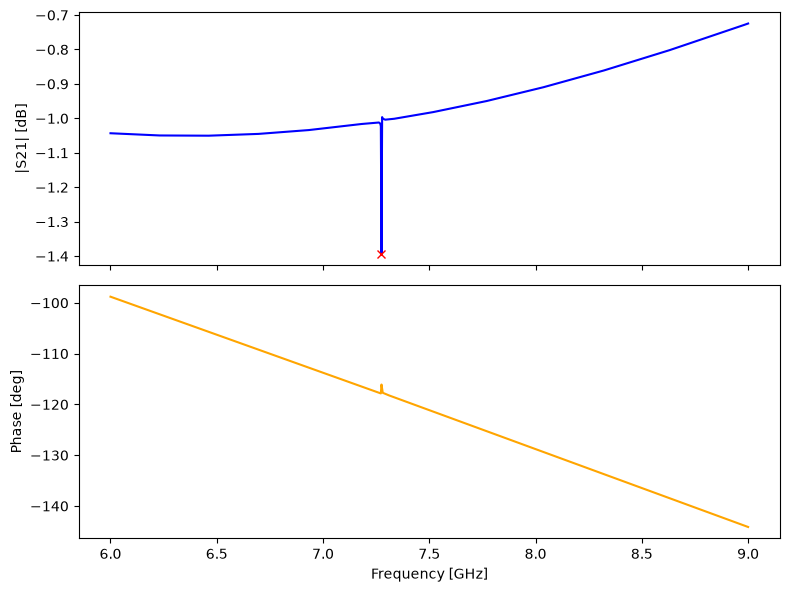

In [45]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


freqs_GHz = res['freqs'] / 1e9

s21 = res['S21']

mod_s21 = 20*np.log10(np.abs(s21))
phase = np.angle(s21, deg=True)

index = np.argmin(mod_s21)


print(f"Resonance frequencies (GHz): {freqs_GHz[index]}")

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
ax[0].plot(freqs_GHz, mod_s21, color='blue')
ax[0].plot(freqs_GHz[index], mod_s21[index], "x", color='red', label='Resonance Peak')
ax[0].set_ylabel('|S21| [dB]')
ax[1].plot(freqs_GHz, phase, color='orange')
ax[1].set_ylabel('Phase [deg]')
ax[1].set_xlabel('Frequency [GHz]')
fig.tight_layout()